# 📦 StockSense — Notebook de démonstration

Ce notebook illustre l'usage concret de la chaîne **StockSense** : charger les données, comparer les modèles, lire une prévision probabiliste, et en déduire une décision de réapprovisionnement.

> Pré-requis : avoir lancé au moins une fois `python -m src.run_pipeline` (crée la base et les prédictions dans `reports/`).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import config
from src.dataset import load_features, load_splits
pd.set_option("display.width", 140)
print("StockSense — répertoire projet:", config.ROOT.name)

StockSense — répertoire projet: stocksense-hackathon


## 1. Les données (table `ml_features`)
Une ligne = (date, magasin, produit) avec la cible `units_sold` et toutes les features (retards, moyennes glissantes, calendrier, change, promo).

In [2]:
feat = load_features()
print("ml_features:", feat.shape)
feat[["date","store_id","product_id","units_sold","price_mga","promo_flag",
      "mga_per_eur","lag_7","roll_mean_7","is_holiday"]].head(8)

ml_features: (263040, 25)


,date,store_id,product_id,units_sold,price_mga,promo_flag,mga_per_eur,lag_7,roll_mean_7,is_holiday
0,2022-01-01,1,1,33,24320.0,0,4324.7,NaN,NaN,1
1,2022-01-02,1,1,18,24494.0,0,4327.6,NaN,33.000000,0
2,2022-01-03,1,1,21,24007.0,0,4327.5,NaN,25.500000,0
3,2022-01-04,1,1,14,24248.0,0,4328.7,NaN,24.000000,0
4,2022-01-05,1,1,21,24256.0,0,4328.6,NaN,21.500000,0
5,2022-01-06,1,1,19,24039.0,0,4329.6,NaN,21.400000,0
6,2022-01-07,1,1,23,24396.0,0,4332.7,NaN,21.000000,0
7,2022-01-08,1,1,20,23980.0,0,4331.2,33.0,21.285714,0


## 2. Découpage temporel (sans fuite)
Le split est strictement chronologique : on entraîne sur le passé, on valide puis on teste sur le futur.

In [3]:
s = load_splits()
print(f"train {s.train.shape}  |  valid {s.valid.shape}  |  test {s.test.shape}")
print(f"période test : {s.test['date'].min().date()} -> {s.test['date'].max().date()}")
print(f"{len(s.feature_columns)} features :", s.feature_columns)

train (212160, 25)  |  valid (22080, 25)  |  test (22080, 25)
période test : 2024-10-01 -> 2024-12-31
21 features : ['price_mga', 'promo_flag', 'is_holiday', 'is_weekend', 'dow', 'month', 'weekofyear', 'mga_per_eur', 'unit_cost_eur', 'is_imported', 'lead_time_days', 'category_id', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'roll_mean_7_lag7', 'days_since_promo']


## 3. Comparaison des modèles (test hold-out)
Le **LSTM** obtient la meilleure erreur (MAE, WMAPE) et la meilleure calibration d'intervalle (couverture ≈ 80 %).

In [4]:
metrics = json.load(open(config.REPORTS_DIR / "metrics.json"))
comp = pd.DataFrame(metrics).T.sort_values("mae")
comp.round(2)

,mae,rmse,mape,wmape,pinball,coverage_80
lstm,3.23,5.11,34.80,18.67,1.03,80.58
hgb,3.37,4.80,37.57,19.44,1.07,78.77
seasonal_naive,5.24,9.05,50.08,30.25,1.84,80.36


## 4. Prévision probabiliste d'un article
Pour chaque (produit, magasin), le modèle fournit une prévision médiane **P50** et un **intervalle P10–P90**. L'intervalle sert directement à dimensionner le stock de sécurité.

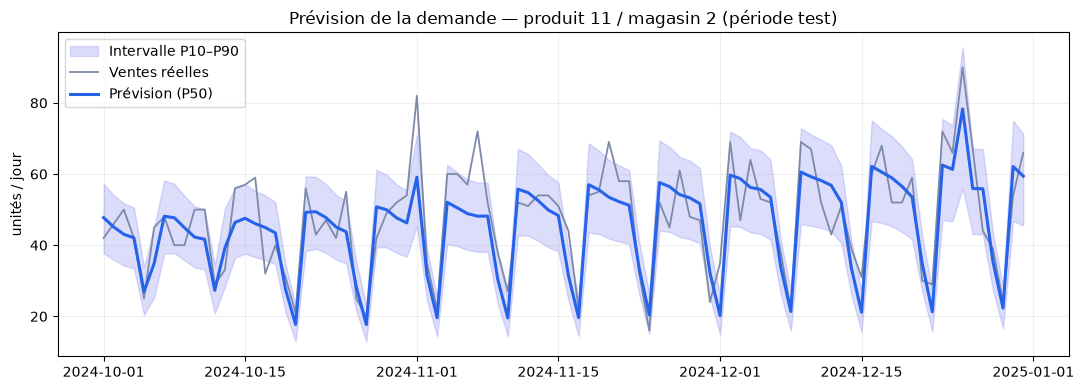

In [5]:
p = pd.read_parquet(config.REPORTS_DIR / "preds_lstm.parquet")
p["date"] = pd.to_datetime(p["date"])
sub = p[(p.product_id == 11) & (p.store_id == 2)].sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(sub.date, sub.y_p10, sub.y_p90, color="#6366f1", alpha=0.22, label="Intervalle P10–P90")
ax.plot(sub.date, sub.y_true, color="#7c8aa8", lw=1.3, label="Ventes réelles")
ax.plot(sub.date, sub.y_pred, color="#2563eb", lw=2.2, label="Prévision (P50)")
ax.set_title("Prévision de la demande — produit 11 / magasin 2 (période test)")
ax.set_ylabel("unités / jour"); ax.grid(alpha=0.2); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 5. De la prévision à la décision de stock
La politique pilotée par la prévision atteint un service quasi équivalent (> 99,5 %) tout en **réduisant fortement le capital immobilisé** par rapport à la pratique courante.

In [6]:
inv = json.load(open(config.REPORTS_DIR / "inventory_summary.json"))
rows = []
for k, v in inv["by_service_level"].items():
    rows.append({
        "service cible": f"{float(k)*100:.0f}%",
        "taux de service (modèle)": f"{v['model_fill_rate']*100:.1f}%",
        "réduction coût total": f"-{v['cost_reduction_pct']:.0f}%",
        "réduction capital stock": f"-{v['stock_value_reduction_pct']:.0f}%",
    })
pd.DataFrame(rows)

,service cible,taux de service (modèle),réduction coût total,réduction capital stock
0,90%,99.5%,-6%,-53%
1,95%,99.6%,-30%,-58%
2,98%,99.8%,-45%,-62%


In [7]:
fx = inv["fx_sensitivity"]
print(f"Sensibilité au taux de change (+10% MGA/EUR) :")
print(f"  - imports = {fx['imported_share_of_holding_pct']:.0f}% du coût de détention")
print(f"  - coût d'immobilisation total du stock : +{fx['extra_holding_cost_total_plus10_pct']:.1f}%")

Sensibilité au taux de change (+10% MGA/EUR) :
  - imports = 80% du coût de détention
  - coût d'immobilisation total du stock : +8.0%


## 6. Exemple concret : point de commande d'un article
À partir de la prévision, on calcule un **point de commande** (ROP) simple : demande moyenne prévue sur le délai de livraison + stock de sécurité déduit de l'intervalle prédictif.

In [8]:
import sqlite3
con = sqlite3.connect(config.DB_PATH)
prod = pd.read_sql_query("SELECT product_id, lead_time_days, is_imported FROM dim_product WHERE product_id=11", con)
con.close()
L = int(prod.lead_time_days.iloc[0])

daily_mean = sub.y_pred.mean()                      # demande moyenne prévue / jour
sigma_day  = ((sub.y_p90 - sub.y_pred) / 1.2816).mean()  # écart-type déduit de l'intervalle P90
z = 1.6449                                          # niveau de service 95%
safety_stock = z * sigma_day * np.sqrt(L)
rop = daily_mean * L + safety_stock

print(f"Article 11 (importé={bool(prod.is_imported.iloc[0])}, délai L={L} j)")
print(f"  demande moyenne prévue      : {daily_mean:.1f} u/j")
print(f"  stock de sécurité (95%)     : {safety_stock:.0f} u")
print(f"  => point de commande (ROP)  : {rop:.0f} u")
print(f"  Interprétation : recommander dès que le stock passe sous {rop:.0f} unités.")

Article 11 (importé=True, délai L=34 j)
  demande moyenne prévue      : 45.3 u/j
  stock de sécurité (95%)     : 71 u
  => point de commande (ROP)  : 1613 u
  Interprétation : recommander dès que le stock passe sous 1613 unités.


---
**Conclusion.** StockSense transforme des ventes historiques en prévisions probabilistes fiables, puis en décisions de stock chiffrées — en tenant compte des délais d'import et du risque de change. Pour l'utiliser sur des données réelles, il suffit de remplacer les tables `fct_sales` / `dim_fx` par les données de l'entreprise et de relancer `python -m src.run_pipeline`.